# 01_Pay_Per_Compute_Serverless_Architecture


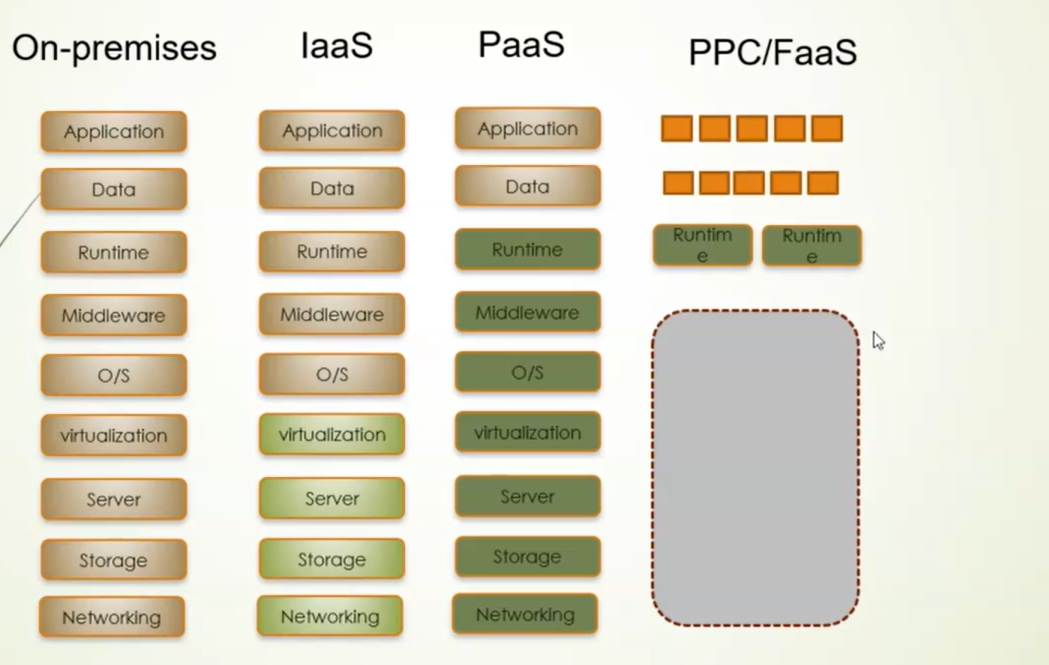

## 1. Big Picture: On‑Premises vs IaaS vs PaaS vs PPC/FaaS

These four models tell you **who manages what** in the computing stack.

### 1.1 The Stack Layers

From bottom to top we usually have:

1. **Networking** – physical network, switches, routers, firewalls, internet connectivity.
2. **Storage** – disks, SSDs, SAN/NAS, backups.
3. **Server (Hardware)** – physical machines, CPUs, RAM, power, racking.
4. **Virtualization / Hypervisor** – software that slices physical servers into multiple VMs (e.g., VMware ESXi, Hyper‑V, KVM).
5. **Operating System (OS)** – Linux, Windows Server, etc.
6. **Middleware** – web servers, application servers, queues, API gateways (e.g., Nginx, Apache, IIS, Tomcat, RabbitMQ).
7. **Runtime** – language/runtime (JVM, .NET CLR, Node.js, Python interpreter, PHP runtime, etc.).
8. **Application** – your code: web app, API, mobile backend, ML service.
9. **Data** – application data: databases, files, logs, analytics data.

Each cloud model decides which layers are your responsibility and which are the provider’s.

---

### 1.2 On‑Premises (Traditional Data Center)

**You manage everything.**

* You own / rent the building, cooling, power.
* You buy and maintain servers, networking gear, storage.
* You install hypervisors, operating systems.
* You configure middleware and runtimes.
* You deploy and manage the application and its data.

**Example:**

* A bank runs a core banking system in its own data center.
* IT team manages Cisco switches, Dell servers, VMware cluster, Oracle DB, WebLogic servers, etc.

**Pros:**

* Full control over hardware and security.
* Can optimize for very specific performance or compliance requirements.

**Cons:**

* High upfront cost (CapEx: capital expenditure).
* Scaling is slow (buy hardware, wait weeks/months).
* You need specialized staff for every layer.

---

### 1.3 IaaS – Infrastructure as a Service

IaaS means **the provider manages the physical infrastructure and virtualization**; you manage the rest.

**Cloud provider manages:**

* Networking
* Storage
* Physical servers
* Virtualization (hypervisor, VM management)

**You manage:**

* Operating System
* Middleware
* Runtime
* Application
* Data

**Visual analogy (based on screenshot "How IaaS Works")**

* Think of a **Virtual Private Cloud (VPC)** as your isolated network in the provider’s data center.
* Inside the VPC you create **subnets** and **virtual machines (VMs)**.
* You choose OS, install software, deploy your app.

**Cloud examples:**

* AWS EC2, Google Compute Engine, Azure Virtual Machines, DigitalOcean Droplets.

**Example scenario:**

* A startup moves their on‑prem web server to AWS EC2.
* They still manage Ubuntu, install Nginx, Node.js, and deploy code.

**Pros:**

* No need to buy/maintain hardware.
* Pay‑as‑you‑go for VM instances.
* Full control over OS and software stack.

**Cons:**

* Still doing patching, OS hardening, scaling.
* Need DevOps expertise (monitoring, auto‑scaling, backups).

---

### 1.4 PaaS – Platform as a Service

PaaS means **the provider manages everything up to the runtime**; you focus on application and data.

**Cloud provider manages:**

* Networking
* Storage
* Servers
* Virtualization
* OS
* Middleware
* Runtime

**You manage:**

* Application
* Data

The screenshot shows a **VPC** with a **PaaS box** (e.g., Beanstalk environment) inside a subnet. The platform hides the VM details and gives you a deployable environment.

**Cloud examples:**

* AWS Elastic Beanstalk
* Heroku
* Google App Engine
* Azure App Service

**Example scenario:**

* You push your Python web app to Heroku.
* Heroku creates containers, installs runtime, scales dynos.
* You only configure environment variables and perhaps add-ons (Postgres, Redis).

**Pros:**

* No OS management or patching.
* Easy deployment (git push, CLI command, or UI upload).
* Automatic scaling and load balancing in many services.

**Cons:**

* Less control over environment (limited OS customization).
* Vendor‑specific constraints (supported languages, versions).
* May be more expensive at scale than raw IaaS.

---

### 1.5 PPC / FaaS – Pay‑Per‑Compute / Function as a Service (Serverless)

**Serverless** (in this context) = **you only pay for compute time your functions actually use**, and you do **not manage servers at all**.

PPC/FaaS often appears in diagrams as **small blocks (functions)** sitting on top of a big grey abstract platform.

**Cloud provider manages:**

* Networking
* Storage (usually some default)
* Servers and capacity
* Virtualization / containers
* OS
* Middleware
* Runtime (Node, Python, Java, etc.)
* Auto‑scaling, health, provisioning

**You manage:**

* Application logic, but written as **functions**.
* Data (external DBs, storage services you integrate with).

**Cloud examples:**

* AWS Lambda
* Azure Functions
* Google Cloud Functions
* Cloudflare Workers

**Key idea:** You upload small pieces of code (functions). The platform runs them **only when triggered** (HTTP request, queue message, file uploaded, cron schedule, etc.) and charges **per execution + compute time**, not per always‑on server.

---

## 2. Deeper into Serverless / PPC / FaaS

### 2.1 Why "Serverless"?

There are still servers physically, but:

* You **don’t provision** them.
* You **don’t manage** their lifecycle.
* You **don’t pay** for idle time (in most models).

From the developer’s point of view, **servers are invisible**, so "serverless".

---

### 2.2 Typical Flow of a Serverless Function

1. **Trigger happens**

   * API Gateway receives HTTP request.
   * A file is uploaded to cloud storage.
   * A message arrives in a queue or event bus.

2. **Platform locates appropriate function** and allocates a runtime container.

3. **Function code runs**

   * Reads input event.
   * Performs business logic.
   * Reads/writes to DB or other services.
   * Returns a response.

4. **Container may be kept warm** for a short time to serve subsequent requests, or is eventually destroyed.

**Example:**

* A user uploads an image to S3.
* S3 triggers a Lambda function.
* Lambda resizes the image to thumbnails and stores them in another bucket.
* You pay for the milliseconds consumed during resizing and memory allocated, not for a full server.

---

### 2.3 Cold Starts and Warm Starts

* **Cold start:** When your function is invoked after a period of inactivity, the platform must create a new container, download code, and initialize runtime. This adds extra latency (e.g., 100ms–1s+ depending on language and provider).
* **Warm start:** If another request arrives soon after, the same container may be reused. Initialization cost is skipped; function runs faster.

**Mitigation strategies:**

* Use lighter runtimes (Node.js, Python generally start faster than Java/.NET).
* Keep functions focused and small (less initialization work).
* Some providers offer *provisioned concurrency* or *always‑on* instances.

---

### 2.4 Event‑Driven Architecture

Serverless fits naturally with **event‑driven** designs:

* Each business action becomes a function triggered by events.
* Example: `userRegistered` event → `SendWelcomeEmailFunction` and `CreateDefaultProfileFunction` run independently.
* Queues and topics (SNS, SQS, Pub/Sub) glue services together.

Benefits:

* Loose coupling between components.
* Easy independent scaling.
* Increased resilience (failed events can be retried).

---

### 2.5 Pricing Model – Pay Per Compute

You generally pay for:

* **Number of invocations** – how many times your function ran.
* **Duration** – time from start to finish, rounded up to nearest time unit (e.g., 1ms or 100ms).
* **Allocated memory/CPU** – you choose a memory tier; CPU scales with it.

**Simple example:**

* A Lambda runs 1 million times in a month.
* Each run lasts 200ms with 512MB memory.
* You pay only for `1,000,000 * 0.2 seconds * 0.5 GB` plus invocation cost.
* If nobody calls your function overnight, cost is basically zero.

Compare with IaaS:

* An EC2 t3.small instance runs 24/7 even if you have traffic only during business hours.
* You still pay for full month usage.

---

### 2.6 When Serverless Shines

1. **Spiky Workloads**

   * Traffic jumps unexpectedly (e.g., viral post, flash sale).
   * Serverless automatically scales from 0 to thousands of executions.

2. **Infrequent Jobs**

   * Nightly report generation.
   * Weekly cleanup of old data.
   * Cron‑like tasks using scheduled triggers.

3. **Microservices and APIs**

   * Each endpoint implemented as a separate function.
   * Easy to deploy and scale parts independently.

4. **Glue Code / Automation**

   * Resize images, transcode videos, transform files.
   * Listen to log streams and send alerts.

---

### 2.7 Limitations and Challenges of Serverless

1. **Execution Time Limits**

   * Many providers cap single function runtime (e.g., 15 minutes for AWS Lambda).
   * Long‑running tasks (e.g., large video render) may need different architecture (batch jobs, containers, step functions).

2. **State Management**

   * Functions are stateless; you can’t store state in memory between invocations.
   * Must externalize state to DBs, caches, message queues.

3. **Complexity at Scale**

   * Many small functions → more difficult to trace and debug.
   * Observability tools (distributed tracing, log aggregation) become essential.

4. **Cold Start Latency**

   * For latency‑sensitive APIs (<50ms), cold starts may hurt user experience.

5. **Vendor Lock‑In**

   * Each provider has its own event model, configuration, and limits.
   * Moving from AWS Lambda to Azure Functions may require code + infrastructure changes.

---

## 3. Comparing IaaS, PaaS, and Serverless Through Examples

### 3.1 Example: Simple REST API for a Todo App

**On‑Premises:**

* Buy a server, install Linux, Nginx, Node.js, PostgreSQL.
* Deploy your Node app.
* Monitor disk, CPU, power, cooling.

**IaaS:**

* Launch an EC2 VM.
* SSH into it, install Node.js and database (or use managed RDS).
* Deploy Node app via PM2 or Docker.
* Set up load balancers and auto‑scaling groups.

**PaaS:**

* Push app code to Elastic Beanstalk / Heroku.
* Choose Node.js platform.
* Platform handles VM provisioning, scaling, and health checks.

**Serverless / FaaS:**

* API Gateway routes `GET /todos`, `POST /todos` to separate Lambda functions.
* Functions read/write from a managed database (e.g., DynamoDB, Aurora Serverless).
* You pay only when API is called.

---

### 3.2 Example: Image Processing Pipeline

**Goal:** When a user uploads a profile picture, generate multiple sizes.

**IaaS Approach:**

* Run a dedicated VM running a background worker.
* Worker watches a queue or folder, processes images using ImageMagick.
* VM is always on.

**PaaS Approach:**

* Similar, but worker is a PaaS app that is always running.

**Serverless Approach:**

* User uploads image to storage bucket.
* Upload event triggers a function.
* Function resizes image and saves outputs.
* After processing, compute cost stops.

Result: With millions of occasional uploads, serverless can be much cheaper and easier to scale.

---